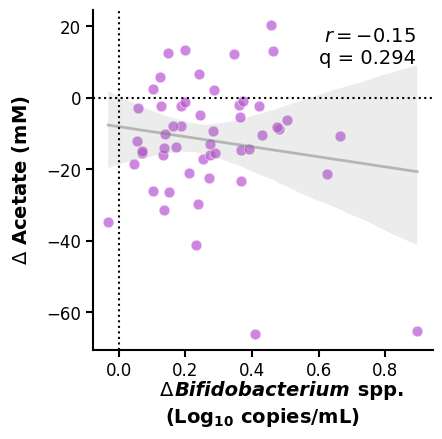

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as multitest
import warnings
import os

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Settings (Publication Quality)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

def clean_and_convert(vals):
    s_vals = pd.Series(vals).astype(str).str.strip()
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], '0')
    s_vals = s_vals.str.replace(r'\.E\+', 'E+', regex=True)
    s_vals = s_vals.str.replace(r'\.E\-', 'E-', regex=True)
    return pd.to_numeric(s_vals, errors='coerce').fillna(0)

# =============================================================================
# 2. Data Loading, Correlation, and FDR Correction
# =============================================================================
# Load Acetate
df_ace = pd.read_csv('Acetate(mM).csv')
donor_cols_ace = [c for c in df_ace.columns if c.startswith('HS-')]
ace_ctrl = clean_and_convert(df_ace[df_ace['KULFFI'].str.strip() == 'Control'][donor_cols_ace].iloc[0])
ace_inulin = clean_and_convert(df_ace[df_ace['KULFFI'].str.strip() == 'Inulin'][donor_cols_ace].iloc[0])
delta_ace = ace_inulin - ace_ctrl

taxa_files = {
    'Bifidobacterium': 'Bifidobacterium(qPCR).csv',
    'Blautia': 'Blautia(qPCR).csv',
    'Faecalibacterium': 'Faecalibacterium(qPCR).csv',
    'Butyricicoccus': 'Butyricicoccus(qPCR).csv',
    'Anaerostipes caccae': 'A.caccae.csv'
}

r_vals = []
p_vals = []
valid_taxa = []
delta_bif_saved = None

for taxon, filename in taxa_files.items():
    if not os.path.exists(filename): continue
    try:
        df = pd.read_csv(filename)
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding='shift_jis')

    donor_cols = [c for c in df.columns if c.startswith('HS-')]
    ctrl_vals = clean_and_convert(df[df['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0])
    inulin_vals = clean_and_convert(df[df['KULFFI'].str.strip() == 'Inulin'][donor_cols].iloc[0])

    delta_taxa = np.log10(inulin_vals + 1) - np.log10(ctrl_vals + 1)

    if taxon == 'Bifidobacterium':
        delta_bif_saved = delta_taxa

    r, p = stats.pearsonr(delta_taxa, delta_ace)
    r_vals.append(r)
    p_vals.append(p)
    valid_taxa.append(taxon)

# FDR Correction against Acetate
_, q_vals, _, _ = multitest.multipletests(p_vals, alpha=0.05, method='fdr_bh')
bif_idx = valid_taxa.index('Bifidobacterium')
r_bif = r_vals[bif_idx]
q_bif = q_vals[bif_idx]

df_plot = pd.DataFrame({
    'Delta_Bifido': delta_bif_saved,
    'Delta_Acetate': delta_ace
})

# =============================================================================
# 3. Figure Generation
# =============================================================================
fig, ax = plt.subplots(figsize=(5, 5))
inulin_color = '#BA55D3'

# Condition: Solid black line if absolute correlation is >= 0.6
if abs(r_bif) >= 0.6:
    line_kws = {'linewidth': 2, 'color': 'black', 'alpha': 1.0, 'linestyle': '-'}
else:
    line_kws = {'linewidth': 2, 'color': 'gray', 'alpha': 0.5, 'linestyle': '-'}

# Scatter plot and regression line (exact match to user's code)
sns.regplot(x='Delta_Bifido', y='Delta_Acetate', data=df_plot, ax=ax, color=inulin_color,
            scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'white', 'linewidths': 0.5},
            line_kws=line_kws)

ax.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax.axvline(0, color='black', linestyle=':', linewidth=1.5)

ax.set_xlabel('')
ax.set_ylabel(r'$\Delta$ Acetate (mM)', fontsize=14, fontweight='bold', labelpad=10)

ax.tick_params(axis='both', labelsize=12, width=1.5, length=5)

for spine in ['left', 'bottom']: ax.spines[spine].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_box_aspect(1)

# Perfectly centered custom X-axis label
x_center = 0.5
y_base = -0.12
bifi_half_width = 0.26

ax.text(x_center, y_base, 'Bifidobacterium', transform=ax.transAxes,
        fontsize=14, fontweight='bold', fontstyle='italic', ha='center', va='center')

ax.text(x_center - bifi_half_width, y_base, r'$\Delta$ ', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='right', va='center')

ax.text(x_center + bifi_half_width, y_base, ' spp.', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='left', va='center')

ax.text(x_center, y_base - 0.08, r'(Log$_{\mathbf{10}}$ copies/mL)', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='center', va='center')

# Stats text (bbox removed)
q_text = "q < 0.001" if q_bif < 0.001 else f"q = {q_bif:.3f}"
stats_text = f"$r = {r_bif:.2f}$\n{q_text}"

# Adaptive positioning
if r_bif > 0.4:
    x_pos, y_pos, va, ha = 0.05, 0.95, 'top', 'left'
elif r_bif < 0:
    x_pos, y_pos, va, ha = 0.95, 0.95, 'top', 'right'
else:
    x_pos, y_pos, va, ha = 0.05, 0.95, 'top', 'left'

ax.text(x_pos, y_pos, stats_text, transform=ax.transAxes,
        fontsize=14, fontweight='normal', va=va, ha=ha, color='black')

plt.subplots_adjust(bottom=0.2)

# =============================================================================
# 4. Output
# =============================================================================
plt.savefig('Figure_4g.pdf', dpi=DPI_SETTING, bbox_inches='tight', transparent=True)